##IMPORT E CARICAMENTO DEI DATI

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import re
import nltk
import torch
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import torch.nn.functional as F

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

from sklearn import metrics
from sklearn.metrics import f1_score, accuracy_score, confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC, LinearSVC
from sklearn.ensemble import VotingClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score

from torch.utils.data import Dataset, DataLoader
from sentence_transformers import SentenceTransformer
from transformers import AutoTokenizer, AutoModelForSequenceClassification, get_linear_schedule_with_warmup

nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
english_stopwords = set(stopwords.words('english'))

df_train = pd.read_csv('data/train.csv')
df_test = pd.read_csv('data/test.csv')

print(f"Righe nel Train Set: {len(df_train)}")
print(f"Righe nel Test Set: {len(df_test)}")

Righe nel Train Set: 7613
Righe nel Test Set: 3263


## EDA - missing values

In [ ]:
print('Valori Mancanti:\n')
missing = df_train.isnull().sum()
print(missing)

Valori Mancanti:

id             0
keyword       61
location    2533
text           0
target         0
dtype: int64


Il numero di valori 'keyword' mancanti è trascurabile, mentre in 'location' abbiamo il circa 33% di valori mancanti. Questo ha senso dato che la geolocalizzazione di twitter è opzionale.

## EDA - Distribuzione classi:




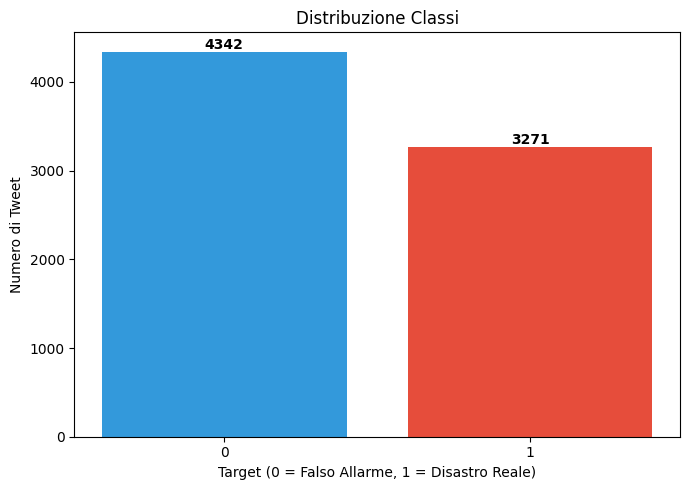

In [ ]:
conteggi = df_train['target'].value_counts()
classi, freq = conteggi.index, conteggi.values

_, axs = plt.subplots(1, 1)
fig = plt.gcf()
fig.set_size_inches(7, 5)
ax = axs

colors = [(0.2, 0.6, 0.86, 1.0), (0.9, 0.3, 0.23, 1.0)]
bars = ax.bar(classi, freq, color=colors)

ax.set(xlabel='Target (0 = Falso Allarme, 1 = Disastro Reale)',
       ylabel='Numero di Tweet',
       title='Distribuzione Classi',
       xticks=classi)

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2.0, height,
            '%d' % int(height), ha='center', va='bottom', fontweight='bold')

fig.tight_layout()
plt.show()

Abbiamo classi sbilanciate: circa il 57% di tweet è classificato come falso allarme, mentre il restante 43% è classificato come disastro reale. Lo sbilanciamento è moderato, in questo caso l'F1-score e il valore AUC sono metriche più affidabili della semplice Accuracy.


##EDA - Lunghezza del testo

In [ ]:
df_train['text_length'] = df_train['text'].apply(lambda x: len(str(x)))
df_train['word_count']  = df_train['text'].apply(lambda x: len(str(x).split()))

print('Statistiche Descrittive per Classe:')
print(df_train.groupby('target')[['text_length','word_count']].describe().round(1))

Statistiche Descrittive per Classe:
       text_length                                               word_count  \
             count   mean   std   min   25%    50%    75%    max      count   
target                                                                        
0           4342.0   95.7  35.9   7.0  68.0  101.0  130.0  157.0     4342.0   
1           3271.0  108.1  29.3  14.0  88.0  115.0  136.0  151.0     3271.0   

                                                
        mean  std  min   25%   50%   75%   max  
target                                          
0       14.7  6.2  1.0  10.0  15.0  19.0  31.0  
1       15.2  5.1  2.0  11.0  15.0  19.0  30.0  


La lunghezza media dei tweet in parole è identica per entrambe le classi, intorno a 15. Guardando invece alla lunghezza in caratteri, la Classe 1 (le emergenze) è in media maggiore, suggerendo che a parità di parole i tweet sui disastri contengono termini mediamente più lunghi (che possiamo associare ad un linguaggio più formale o alla preenza di URL che indicano la condivisione di notizie reali).



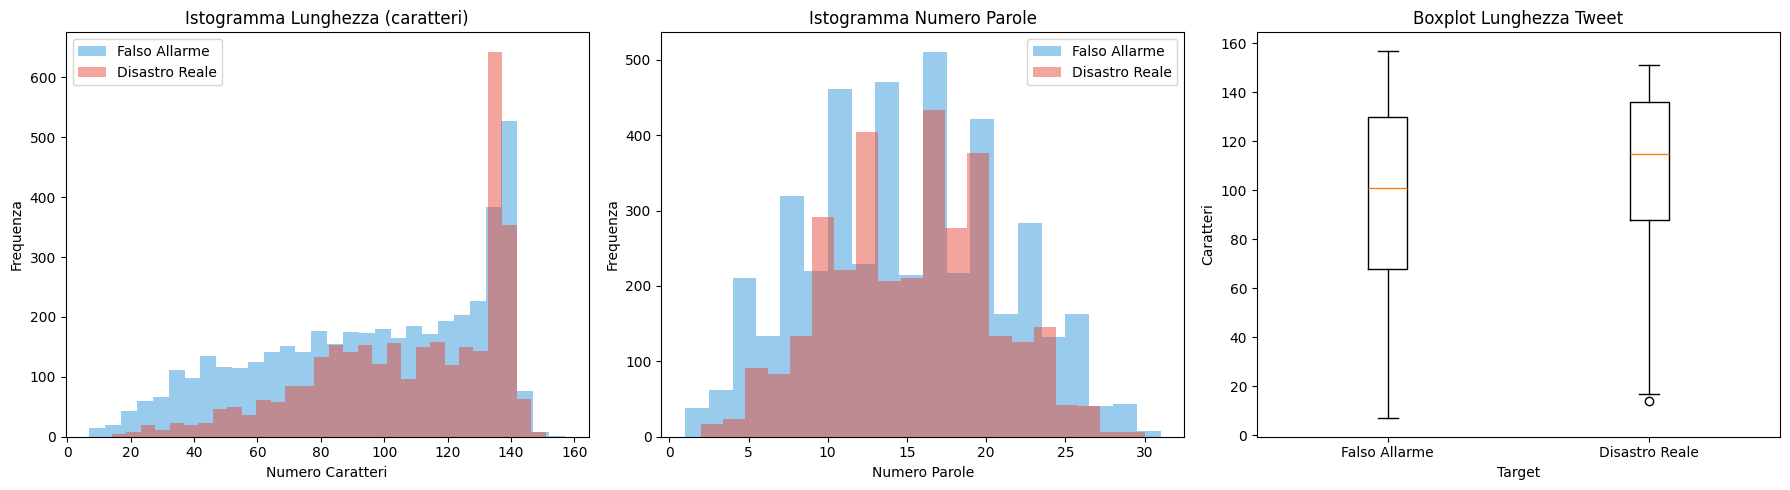

In [ ]:
len_0 = df_train[df_train['target'] == 0]['text_length']
len_1 = df_train[df_train['target'] == 1]['text_length']
word_0 = df_train[df_train['target'] == 0]['word_count']
word_1 = df_train[df_train['target'] == 1]['word_count']

fig, axs = plt.subplots(1, 3, figsize=(18, 5))

axs[0].hist(len_0, bins=30, color=(0.2, 0.6, 0.86), alpha=0.5, label='Falso Allarme')
axs[0].hist(len_1, bins=30, color=(0.9, 0.3, 0.23), alpha=0.5, label='Disastro Reale')
axs[0].set(xlabel='Numero Caratteri', ylabel='Frequenza', title='Istogramma Lunghezza (caratteri)')
axs[0].legend()

axs[1].hist(word_0, bins=20, color=(0.2, 0.6, 0.86), alpha=0.5, label='Falso Allarme')
axs[1].hist(word_1, bins=20, color=(0.9, 0.3, 0.23), alpha=0.5, label='Disastro Reale')
axs[1].set(xlabel='Numero Parole', ylabel='Frequenza', title='Istogramma Numero Parole')
axs[1].legend()

axs[2].boxplot([len_0, len_1], tick_labels=['Falso Allarme', 'Disastro Reale'])
axs[2].set(xlabel='Target', ylabel='Caratteri', title='Boxplot Lunghezza Tweet')

plt.tight_layout()
plt.show()

Dai grafici e dalle statistiche emerge che:

1.  Il numero di parole non è discriminante. L'istogramma centrale ci mostra che le due classi hanno distribuzioni molto simili, con una media di circa 15 parole per tweet in entrambi i casi.

2.  I veri disastri richiedono più caratteri. L'istogramma di sinistra e il boxplot rivelano che i tweet legati a vere emergenze sono mediamente più lunghi in termini di caratteri e presentano una varianza minore.

##EDA - parole chiave per classe

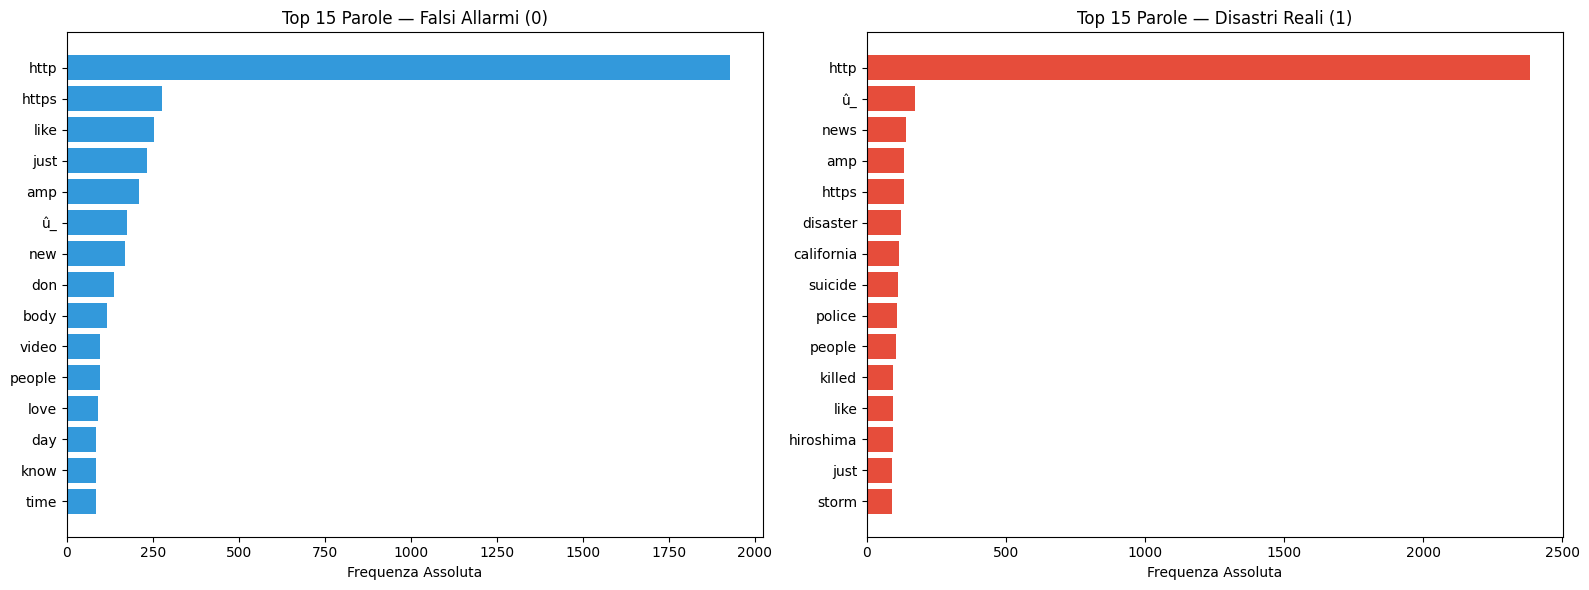

In [ ]:
def get_top_words(corpus, n=15):
    vectorizer = CountVectorizer(analyzer='word', stop_words='english')
    X = vectorizer.fit_transform(corpus)

    sum_words = np.array(X.sum(axis=0)).flatten()
    words = vectorizer.get_feature_names_out()

    freq = list(zip(words, sum_words))
    return sorted(freq, key=lambda x: x[1], reverse=True)[:n]

top0 = get_top_words(df_train[df_train['target']==0]['text'].dropna())
top1 = get_top_words(df_train[df_train['target']==1]['text'].dropna())

words_0, counts_0 = zip(*top0)
words_1, counts_1 = zip(*top1)

fig, axs = plt.subplots(1, 2)
fig.set_size_inches(16, 6)

ax1 = axs[0]
ax1.barh(words_0, counts_0, color=(0.2, 0.6, 0.86, 1.0))
ax1.set(xlabel='Frequenza Assoluta', title='Top 15 Parole — Falsi Allarmi (0)')
ax1.invert_yaxis()

ax2 = axs[1]
ax2.barh(words_1, counts_1, color=(0.9, 0.3, 0.23, 1.0))
ax2.set(xlabel='Frequenza Assoluta', title='Top 15 Parole — Disastri Reali (1)')
ax2.invert_yaxis()

fig.tight_layout()
plt.show()

L'estrazione delle top 15 parole chiave mostra una separazione nel vocabolario delle de classi, con un lessico tipicamente informale (like, love, day), mentre i veri disastri sono caratterizzati da una terminologia tipicamente giornalistica o di emergenza (news, police, killed, storm). Tuttavia la predominanza di tag HTML e URL suggerisce la necessità di ripulire il testo per migliorare successivamente la classificazione dei modelli utilizzati.

## Data Cleaning e Features Engineering:
Ripuliamo il testo contenuto nella variabile 'text' convertendo tutto in minuscolo, rimuovendo i link URL che iniziano con http, https o www. e eliminando le menzioni agli utenti. Inoltre eliminiamo il cancelletto degli hashtag mantenendo tuttavia l'intera parola, la quale potrebbe essere informativa per la classificazione.
In questa fase è sta anche unita la variabile 'keyward' ripulita al corpo del tweet.

In [ ]:
def clean_text(text):
    if not isinstance(text, str):
        return ''
    text = text.lower()
    text = re.sub(r'http\S+|https\S+|www\.\S+', ' ', text) # Rimuove URL
    text = re.sub(r'@\w+', ' ', text)                      # Rimuove menzioni
    text = re.sub(r'#(\w+)', r'\1', text)                  # Rimuove l'hash ma tiene la parola

    tokens = word_tokenize(text)

    tokens = [word for word in tokens if word.isalnum() and word not in english_stopwords]

    return ' '.join(tokens)

df_train['keyword'] = df_train['keyword'].fillna('').str.replace('%20', ' ')
df_test['keyword'] = df_test['keyword'].fillna('').str.replace('%20', ' ')

df_train['clean_text'] = df_train['text'].apply(clean_text)
df_test['clean_text'] = df_test['text'].apply(clean_text)

df_train['clean_full_text'] = df_train['keyword'] + ' ' + df_train['clean_text']
df_test['clean_full_text'] = df_test['keyword'] + ' ' + df_test['clean_text']

 Dato che verranno utilizzati due approcci di classificazione basati su TF-IDF e Transformer, è stato conservato il testo originale non ripulito in modo da sfruttare i meccanismo di Self-Attention che estraggono contesto semantico anche dalla formattazione grezza (che normalmente nei modelli classici verrebbe considerata rumore).

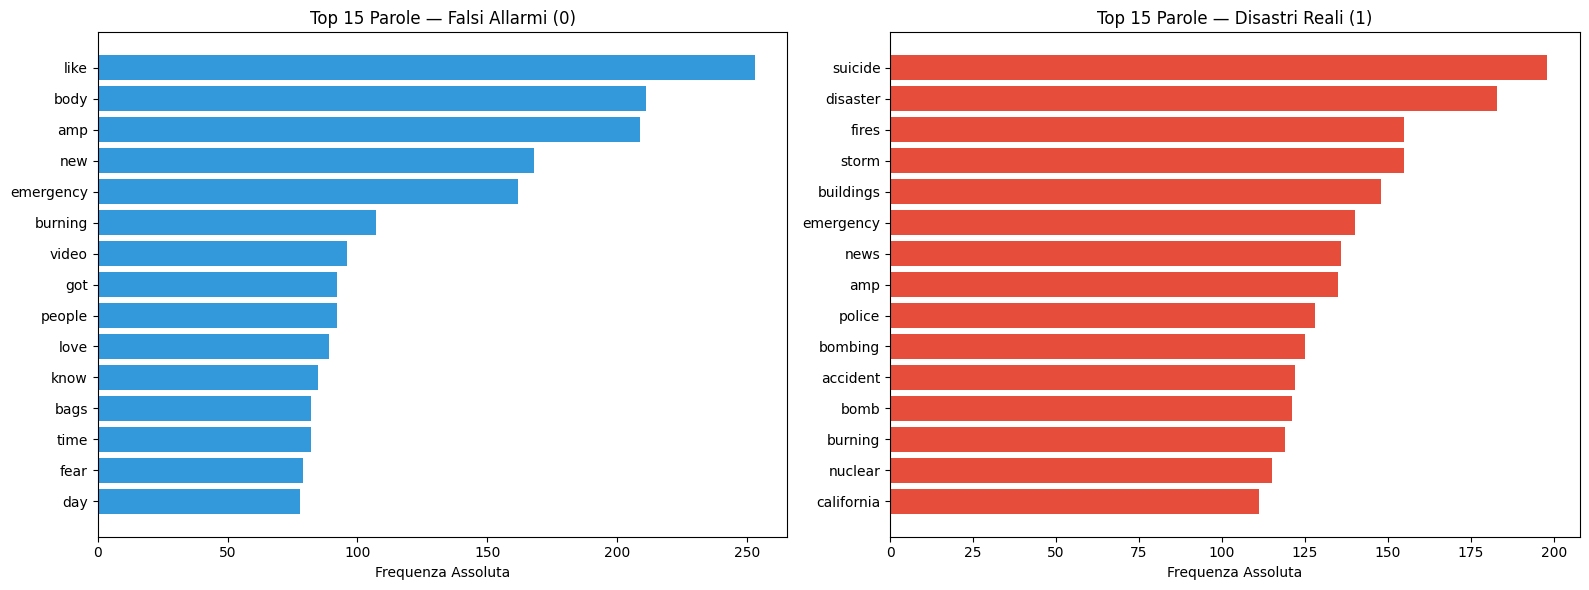

In [ ]:
top0 = get_top_words(df_train[df_train['target']==0]['clean_full_text'])
top1 = get_top_words(df_train[df_train['target']==1]['clean_full_text'])

words_0, counts_0 = zip(*top0)
words_1, counts_1 = zip(*top1)

fig, axs = plt.subplots(1, 2)
fig.set_size_inches(16, 6)

ax1 = axs[0]
ax1.barh(words_0, counts_0, color=(0.2, 0.6, 0.86, 1.0))
ax1.set(xlabel='Frequenza Assoluta', title='Top 15 Parole — Falsi Allarmi (0)')
ax1.invert_yaxis()

ax2 = axs[1]
ax2.barh(words_1, counts_1, color=(0.9, 0.3, 0.23, 1.0))
ax2.set(xlabel='Frequenza Assoluta', title='Top 15 Parole — Disastri Reali (1)')
ax2.invert_yaxis()

fig.tight_layout()
plt.show()

## Modello 1 — Logistic Regression su TF-IDF (Baseline)

Il primo modello è la baseline: il punto di partenza rispetto al quale misurare il miglioramento dei modelli
successivi. Combina due componenti:

Step 1 — Vettorizzazione TF-IDF
Il TF-IDF converte ogni tweet da stringa di testo a vettore numerico. Ogni dimensione del vettore corrisponde
a una parola del vocabolario.
TF-IDF: Per ogni parola in ogni tweet calcola TF (frequenza nel tweet, con log se
sublinear_tf=True) × IDF (log(N/df) dove N=totale tweet, df=tweet che contengono quella parola). Parole
comuni come 'fire' in ogni tweet avranno IDF basso; parole rare ma specifiche avranno IDF alto. Il vettore
risultante è sparso (quasi tutto zeri, solo le parole presenti hanno valore > 0).

Step 2 — Logistic Regression
La LR impara un iperpiano nello spazio TF-IDF a 10.000 dimensioni che separa la classe 0 dalla classe 1.
Ad ogni parola assegna un coefficiente: positivo → spinge verso 'disastro', negativo → spinge verso 'falso
allarme'.

In [ ]:
tfidf_vectorizer = TfidfVectorizer(
    stop_words='english', max_features=10000,
    ngram_range=(1, 2), sublinear_tf=True, min_df=3
)

X_train_tfidf = tfidf_vectorizer.fit_transform(df_train['clean_full_text'])
y_train       = df_train['target']

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_tfidf, y_train, test_size=0.2, random_state=42
)

clf_lr = LogisticRegression(C=5, random_state=42, max_iter=1000)
clf_lr.fit(X_tr, y_tr)

pred_labels_lr = clf_lr.predict(X_val)

acc_lr  = metrics.accuracy_score(y_val, pred_labels_lr)
prec_lr = metrics.precision_score(y_val, pred_labels_lr, average='binary')
rec_lr  = metrics.recall_score(y_val, pred_labels_lr, average='binary')
f1_lr   = metrics.f1_score(y_val, pred_labels_lr, average='binary')

print(f"Accuracy : {acc_lr:.4f}")
print(f"Precision: {prec_lr:.4f}")
print(f"Recall   : {rec_lr:.4f}")
print(f"F1-Score : {f1_lr:.4f}")

Accuracy : 0.7945
Precision: 0.7772
Recall   : 0.7257
F1-Score : 0.7506


stop_words: Rimuove automaticamente articoli e preposizioni inglesi

max_features: Vocabolario limitato alle 10k parole più frequenti

ngram_range: Include sia parole singole che coppie ("not disaster" ≠ "disaster")

sublinear_tf:  TF = 1+log(tf) invece del conteggio grezzo — riduce il peso di ripetizioni

min_df: gnora parole che appaiono in meno di 3 tweet — evita overfitting


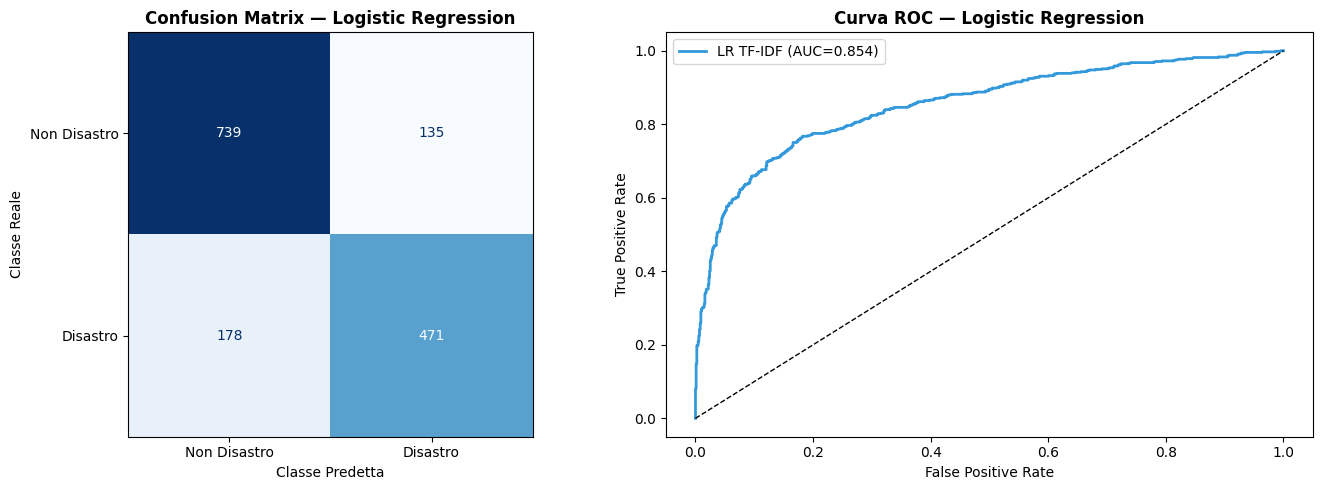

In [ ]:
cm_lr = metrics.confusion_matrix(y_val, pred_labels_lr)

fig, axs = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axs[0]
disp = metrics.ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=['Non Disastro', 'Disastro'])
disp.plot(ax=ax1, cmap='Blues', colorbar=False)
ax1.set_title('Confusion Matrix — Logistic Regression', fontweight='bold')
ax1.set(xlabel='Classe Predetta', ylabel='Classe Reale')
ax1.grid(False)

ax2 = axs[1]
y_prob_lr = clf_lr.predict_proba(X_val)[:, 1]
fpr_lr, tpr_lr, _ = metrics.roc_curve(y_val, y_prob_lr)
auc_val = metrics.auc(fpr_lr, tpr_lr)

ax2.plot(fpr_lr, tpr_lr, color=(0.2, 0.6, 0.86, 1.0), lw=2, label=f'LR TF-IDF (AUC={auc_val:.3f})')
ax2.plot([0, 1], [0, 1], color='k', linestyle='--', lw=1)
ax2.set_title('Curva ROC — Logistic Regression', fontweight='bold')
ax2.set(xlabel='False Positive Rate', ylabel='True Positive Rate')
ax2.legend()

fig.tight_layout()
plt.show()

#RISULTATI:

*   Precision (0.7772):  gli elementi classificati correttamente come positivi sono circa il 78%, con un numero di falsi positivi relativamente basso (135).

*   Recall (0.7257): punto debole del modello, riesce a classificare correttamente solo il 72% dei disastri reali, con 178 falsi negativi. In un contesto di emergenza questo valore è l'errore più grave che il modello potrebbe commettere.

*   AUC (0.854): il modello ha una buona capacità predittiva e distingue relativamente bene le due classi.


## Modello 2 — SVM su TF-IDF

Il secondo modello usa la stessa rappresentazione TF-IDF del Modello 1, ma sostituisce la Logistic
Regression con un Support Vector Machine lineare. L'obiettivo era verificare se un algoritmo di
classificazione diverso migliorasse le performance sulla stessa rappresentazione.

Come funziona SVM (LinearSVC):

L'SVM cerca l'iperpiano ottimale che massimizza il margine tra le due classi: cioè non si accontenta di
separare i dati, ma vuole che i punti più vicini al confine (chiamati Support Vectors) siano il più lontano
possibile dall'iperpiano. Con dati lineari (come TF-IDF sparso), LinearSVC è spesso molto efficiente.


In [ ]:
clf_SVC = CalibratedClassifierCV(LinearSVC(C=1.0, random_state=42, max_iter=2000), cv=3)
clf_SVC.fit(X_tr, y_tr)

pred_labels_SVC = clf_SVC.predict(X_val)

acc_lr  = metrics.accuracy_score(y_val, pred_labels_SVC)
prec_lr = metrics.precision_score(y_val, pred_labels_SVC, average='binary')
rec_lr  = metrics.recall_score(y_val, pred_labels_SVC, average='binary')
f1_lr   = metrics.f1_score(y_val, pred_labels_SVC, average='binary')

print(f"Accuracy : {acc_lr:.4f}")
print(f"Precision: {prec_lr:.4f}")
print(f"Recall   : {rec_lr:.4f}")
print(f"F1-Score : {f1_lr:.4f}")

Accuracy : 0.7991
Precision: 0.7863
Recall   : 0.7257
F1-Score : 0.7548


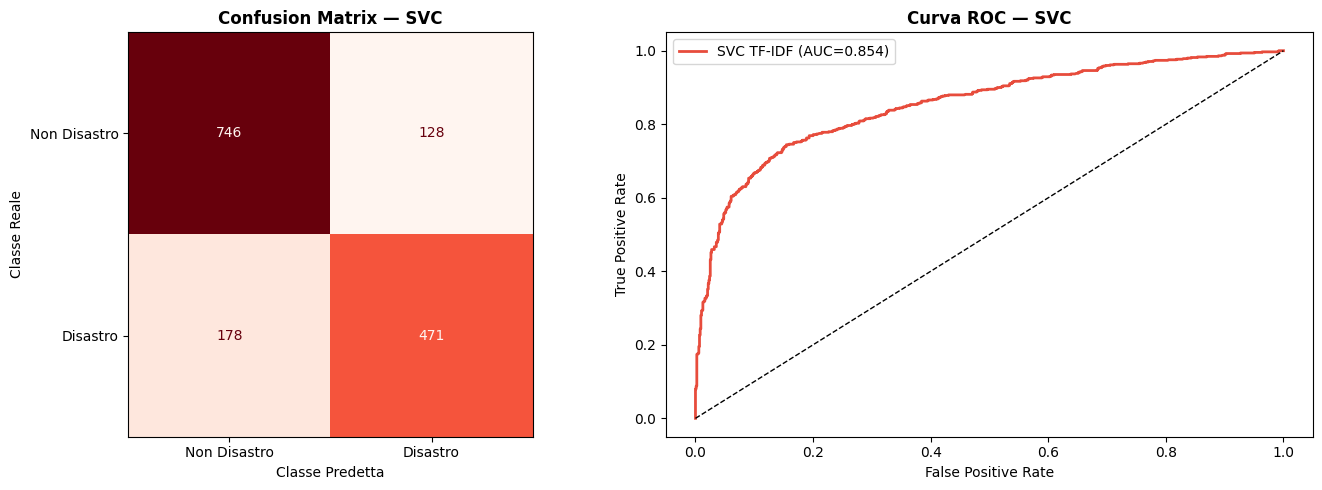

In [ ]:
cm_svc = metrics.confusion_matrix(y_val, pred_labels_SVC)

fig, axs = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axs[0]
disp = metrics.ConfusionMatrixDisplay(confusion_matrix=cm_svc, display_labels=['Non Disastro', 'Disastro'])
disp.plot(ax=ax1, cmap='Reds', colorbar=False)
ax1.set_title('Confusion Matrix — SVC', fontweight='bold')
ax1.set(xlabel='Classe Predetta', ylabel='Classe Reale')
ax1.grid(False)

ax2 = axs[1]
y_prob_svc = clf_SVC.predict_proba(X_val)[:, 1]
fpr_svc, tpr_svc, _ = metrics.roc_curve(y_val, y_prob_svc)
auc_val_svc = metrics.auc(fpr_svc, tpr_svc)

ax2.plot(fpr_svc, tpr_svc, color='#e74c3c', lw=2, label=f'SVC TF-IDF (AUC={auc_val_svc:.3f})')
ax2.plot([0, 1], [0, 1], color='k', linestyle='--', lw=1)
ax2.set_title('Curva ROC — SVC', fontweight='bold')
ax2.set(xlabel='False Positive Rate', ylabel='True Positive Rate')
ax2.legend()

fig.tight_layout()
plt.show()

Confrontando i due modelli notiamo che le prestazioni sono pressoché identiche.
Perché sono quasi identici?

Entrambi i modelli vedono la stessa rappresentazione TF-IDF. LR e LinearSVC trovano
entrambi un iperpiano lineare nello spazio delle feature. Con dati di testo sparsi ad alta dimensione, le due tecniche
tendono a convergere verso soluzioni molto simili. Il ceiling del TF-IDF è già stato raggiunto da LR: cambiare
classificatore lineare non porta guadagni significativi.

## Modello 3 — Ensemble LR + SVM

Il terzo modello combina LR e SVM in un classificatore Ensemble usando la tecnica del Soft Voting. L'idea
è che due modelli insieme possano compensarsi a vicenda e sbagliare meno.

Cos'è un Ensemble?
Un Ensemble combina le predizioni di più modelli. Esistono due varianti principali:

Hard Voting  Ogni modello vota 0 o 1, vince la maggioranza

Soft Voting Si sommano le probabilità p(classe=1) di ogni modello
e si sceglie la classe con media più alta

In [ ]:
clf_EN = VotingClassifier(
    estimators=[
        ('lr',  LogisticRegression(C=5, max_iter=1000, random_state=42)),
        ('svc', CalibratedClassifierCV(LinearSVC(C=1.0, max_iter=2000, random_state=42), cv=3))
    ],
    voting='soft'
)

clf_EN.fit(X_tr, y_tr)

pred_labels_EN = clf_EN.predict(X_val)

acc_lr  = metrics.accuracy_score(y_val, pred_labels_EN)
prec_lr = metrics.precision_score(y_val, pred_labels_EN, average='binary')
rec_lr  = metrics.recall_score(y_val, pred_labels_EN, average='binary')
f1_lr   = metrics.f1_score(y_val, pred_labels_EN, average='binary')

print(f"Accuracy : {acc_lr:.4f}")
print(f"Precision: {prec_lr:.4f}")
print(f"Recall   : {rec_lr:.4f}")
print(f"F1-Score : {f1_lr:.4f}")

Accuracy : 0.7965
Precision: 0.7792
Recall   : 0.7288
F1-Score : 0.7532


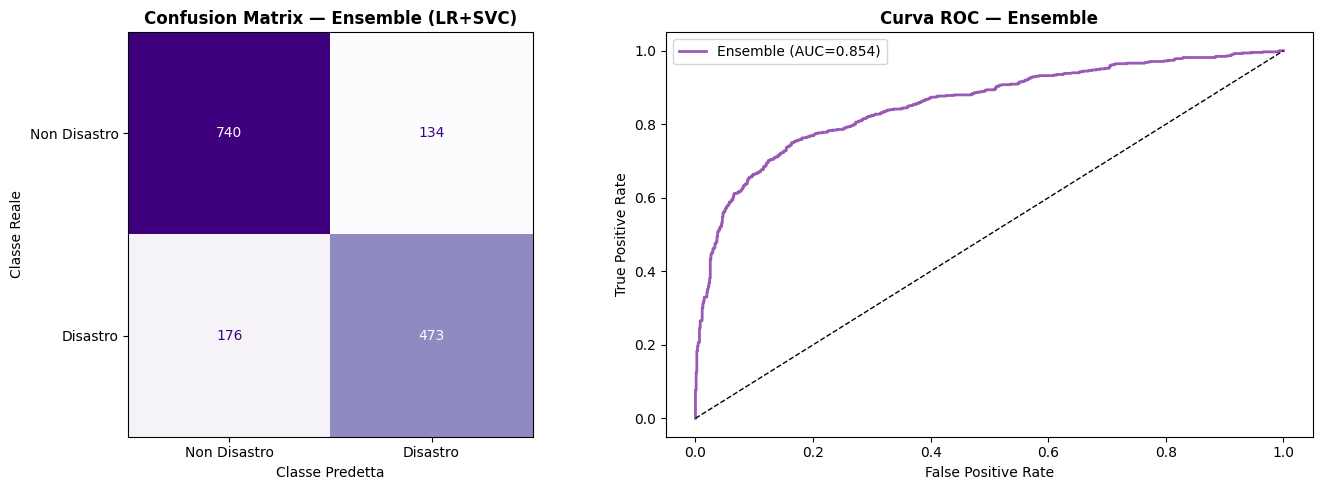

In [ ]:
cm_ens = metrics.confusion_matrix(y_val, pred_labels_EN)

fig, axs = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axs[0]
disp = metrics.ConfusionMatrixDisplay(confusion_matrix=cm_ens, display_labels=['Non Disastro', 'Disastro'])
disp.plot(ax=ax1, cmap='Purples', colorbar=False)
ax1.set_title('Confusion Matrix — Ensemble (LR+SVC)', fontweight='bold')
ax1.set(xlabel='Classe Predetta', ylabel='Classe Reale')
ax1.grid(False)

ax2 = axs[1]
y_prob_ens = clf_EN.predict_proba(X_val)[:, 1]
fpr_ens, tpr_ens, _ = metrics.roc_curve(y_val, y_prob_ens)
auc_val_ens = metrics.auc(fpr_ens, tpr_ens)

ax2.plot(fpr_ens, tpr_ens, color='#9b59b6', lw=2, label=f'Ensemble (AUC={auc_val_ens:.3f})')
ax2.plot([0, 1], [0, 1], color='k', linestyle='--', lw=1)
ax2.set_title('Curva ROC — Ensemble', fontweight='bold')
ax2.set(xlabel='False Positive Rate', ylabel='True Positive Rate')
ax2.legend()

fig.tight_layout()
plt.show()

Per tentare di massimizzare le performance, sono stati combinati i due modelli precedenti in un classificatore Ensemble (Voting). Tuttavia, le metriche ottenute (Accuracy: ~80%, F1-Score: 0.755) e la Matrice di Confusione sono identiche a quelle della singola Regressione Logistica.

Condizione necessaria per il guadagno di un Ensemble: i modelli devono commettere errori diversi e
complementari quando uno sbaglia, l'altro deve avere ragione. Questo si chiama diversificazione degli errori.





## Analisi dei coefficienti della Regressione Logistica


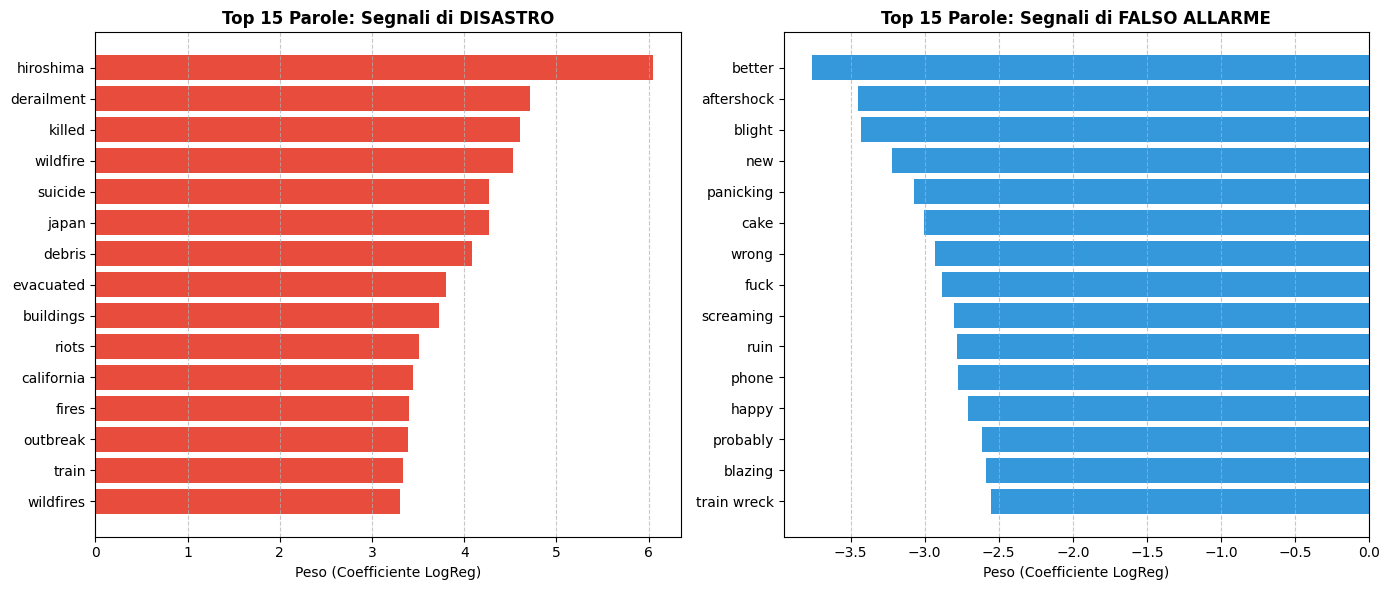

In [ ]:
feature_names = np.array(tfidf_vectorizer.get_feature_names_out())
coefs = clf_lr.coef_[0]

df_coefs = pd.DataFrame({'Parola': feature_names, 'Peso': coefs})

top_disaster = df_coefs.sort_values(by='Peso', ascending=False).head(15)
top_non_disaster = df_coefs.sort_values(by='Peso', ascending=True).head(15)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].barh(top_disaster['Parola'], top_disaster['Peso'], color='#e74c3c')
axes[0].set_title('Top 15 Parole: Segnali di DISASTRO', fontweight='bold')
axes[0].set_xlabel('Peso (Coefficiente LogReg)')
axes[0].invert_yaxis()
axes[0].grid(axis='x', linestyle='--', alpha=0.7)

axes[1].barh(top_non_disaster['Parola'], top_non_disaster['Peso'], color='#3498db')
axes[1].set_title('Top 15 Parole: Segnali di FALSO ALLARME', fontweight='bold')
axes[1].set_xlabel('Peso (Coefficiente LogReg)')
axes[1].invert_yaxis()
axes[1].grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

## Interpretazione dei Coefficienti del Modello

L'analisi dei coefficienti della Regressione Logistica ci permette di capire quali parole pesano di più nella sua fase di decisione.

Osservando il grafico sottostante:
* I **coefficienti positivi più alti (in rosso)** indicano le parole che il modello associa maggiormente a un *Disastro Reale*. La presenza di questi termini nel testo spinge matematicamente il modello a classificare il tweet come un'emergenza.
* Al contrario, i **coefficienti negativi (in azzurro)** rappresentano le parole fortemente associate ai *Falsi Allarmi* o a conversazioni quotidiane.

Tuttavia, da questa analisi emerge anche il principale limite dell'approccio TF-IDF: valutando le parole in modo isolato e basandosi solo sulla loro frequenza, il modello perde il contesto generale della frase. Questo spiega perché alcuni termini ambigui o usati in senso metaforico potrebbero finire per avere un peso imprevisto, confermando l'utilità di esplorare successivamente modelli più avanzati (come i Transformers) in grado di catturare l'intera semantica del testo.

## Modello 4 — LLM Embeddings (all-mpnet-base-v2) + Logistic Regression

I tweet sono stati rappresentati tramite vettori densi (Embeddings) per catturarne il contesto semantico, mentre la classificazione è stata affidata a un modello di Logistic Regression. Per cercare di migliorare ulteriormente il modello, è stata condotta un'ottimizzazione della soglia decisionale (Threshold Tuning). L'obiettivo di questa operazione è massimizzare la metrica F1-Score e ridurre il numero di Falsi Negativi, incrementando così la capacità del classificatore di catturare le emergenze reali.

In [ ]:
def remove_urls(text):
    if not isinstance(text, str):
        return ''
    return re.sub(r'https?:\/\/\S+|www\.\S+', '', text)

df_train['text_no_url'] = df_train['text'].apply(remove_urls)
df_test['text_no_url']  = df_test['text'].apply(remove_urls)

df_train['raw_full_text'] = df_train['keyword'] + ' ' + df_train['text_no_url']
df_test['raw_full_text']  = df_test['keyword']  + ' ' + df_test['text_no_url']

In [ ]:
embedding_model = SentenceTransformer('all-mpnet-base-v2')

X_train_emb = embedding_model.encode(df_train['raw_full_text'].tolist(), show_progress_bar=True)
X_test_emb  = embedding_model.encode(df_test['raw_full_text'].tolist(), show_progress_bar=True)
print(f'Dimensione vettori embedding: {X_train_emb.shape}')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/11.6k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/238 [00:00<?, ?it/s]

Batches:   0%|          | 0/102 [00:00<?, ?it/s]

Dimensione vettori embedding: (7613, 768)


In [ ]:
X_tr_emb, X_val_emb, y_tr_emb, y_val_emb = train_test_split(
    X_train_emb, y_train, test_size=0.2, random_state=42
)

logistic_model_emb = LogisticRegression(C=5, random_state=42, max_iter=1000)
logistic_model_emb.fit(X_tr_emb, y_tr_emb)
y_pred_emb = logistic_model_emb.predict(X_val_emb)

# Calcolo metriche standard (soglia 0.5)
acc_lr  = metrics.accuracy_score(y_val_emb, y_pred_emb)
prec_lr = metrics.precision_score(y_val_emb, y_pred_emb, average='binary')
rec_lr  = metrics.recall_score(y_val_emb, y_pred_emb, average='binary')
f1_lr   = metrics.f1_score(y_val_emb, y_pred_emb, average='binary')

# TUNING valore soglia
y_prob_emb  = logistic_model_emb.predict_proba(X_val_emb)[:, 1]
thresholds   = np.arange(0.3, 0.7, 0.01)
best_thresh  = max(thresholds, key=lambda t: metrics.f1_score(y_val_emb, y_prob_emb > t))
y_pred_emb_t = (y_prob_emb > best_thresh).astype(int)

f1_emb_t     = metrics.f1_score(y_val_emb, y_pred_emb_t)
acc_emb_t    = metrics.accuracy_score(y_val_emb, y_pred_emb_t)

print(f"Accuracy : {acc_lr:.4f}")
print(f"Precision: {prec_lr:.4f}")
print(f"Recall   : {rec_lr:.4f}")
print(f"F1-Score : {f1_lr:.4f}")
print("-"*30)
print(f'F1 con soglia ottimale ({best_thresh:.2f}): {f1_emb_t:.4f}')

Accuracy : 0.8280
Precision: 0.8263
Recall   : 0.7550
F1-Score : 0.7890
------------------------------
F1 con soglia ottimale (0.48): 0.7892


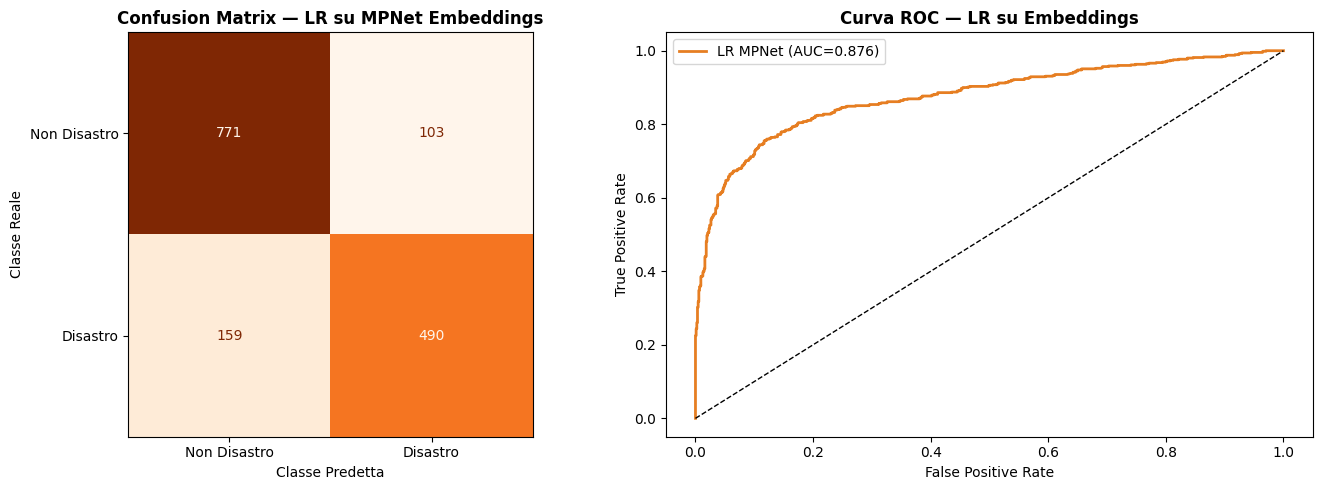

In [ ]:
cm_emb = metrics.confusion_matrix(y_val_emb, y_pred_emb)

fig, axs = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axs[0]
disp = metrics.ConfusionMatrixDisplay(confusion_matrix=cm_emb, display_labels=['Non Disastro', 'Disastro'])
disp.plot(ax=ax1, cmap='Oranges', colorbar=False)
ax1.set_title('Confusion Matrix — LR su MPNet Embeddings', fontweight='bold')
ax1.set(xlabel='Classe Predetta', ylabel='Classe Reale')
ax1.grid(False)

ax2 = axs[1]
y_prob_emb = logistic_model_emb.predict_proba(X_val_emb)[:, 1]
fpr_emb, tpr_emb, _ = metrics.roc_curve(y_val_emb, y_prob_emb)
auc_val_emb = metrics.auc(fpr_emb, tpr_emb)

ax2.plot(fpr_emb, tpr_emb, color='#e67e22', lw=2, label=f'LR MPNet (AUC={auc_val_emb:.3f})')
ax2.plot([0, 1], [0, 1], color='k', linestyle='--', lw=1)
ax2.set_title('Curva ROC — LR su Embeddings', fontweight='bold')
ax2.set(xlabel='False Positive Rate', ylabel='True Positive Rate')
ax2.legend()

fig.tight_layout()
plt.show()

Confrontando questa matrice con quella del modello TF-IDF si nota un miglioramento in entrambi i tipi di errore:

* Falsi Negativi: Sono diminuiti a 159.
* Falsi Positivi: Anche i falsi allarmi sono diminuiti (103), alzando la Precision a ~82%. Questo dimostra che gli embedding riescono a distinguere molto bene l'uso letterale delle parole dal loro uso colloquiale.
* Curva ROC e AUC: Maggiore separabilità delle classi, anche se l'incremento é trascurabile.
* Valutazione delle Metriche e Thresholding
Il modello raggiunge un'Accuracy globale dell'82% e un F1-Score di 0.7890 con la soglia standard. L'operazione di Threshold Tuning ha individuato la soglia decisionale ottimale a 0.48, portando a un F1-Score di 0.7892. La threshold di default era già ottimale, quindi molti esempi vengono classificati con confidenza elevata.

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

modelli_da_testare = [
    ('Logistic Regression (TF-IDF)', clf_lr, X_tr, y_tr),
    ('SVM (TF-IDF)', clf_SVC, X_tr, y_tr),
    ('Ensemble (LR + SVM)', clf_EN, X_tr, y_tr),
    ('LR (MPNet Embeddings)',  logistic_model_emb, X_tr_emb, y_tr_emb)
]

for nome, modello, X, y in modelli_da_testare:
    scores = cross_val_score(modello, X, y, cv=skf, scoring='f1', n_jobs=-1)

    media_f1 = scores.mean()
    deviazione_std = scores.std()

    print(f"{nome}")
    print(f"F1-Score Medio: {media_f1:.4f} (± {deviazione_std:.4f})")
    print("-" * 50)

Logistic Regression (TF-IDF)
F1-Score Medio: 0.7396 (± 0.0104)
--------------------------------------------------
SVM (TF-IDF)
F1-Score Medio: 0.7408 (± 0.0125)
--------------------------------------------------
Ensemble (LR + SVM)
F1-Score Medio: 0.7401 (± 0.0135)
--------------------------------------------------
LR (MPNet Embeddings)
F1-Score Medio: 0.7771 (± 0.0092)
--------------------------------------------------


I risultati della cross-validation mostrano innanzitutto una buona stabilità di tutti i modelli, confermata dalla deviazione standard molto bassa (circa ±0.01). Questo indica che le performance ottenute non dipendono da una particolare suddivisione del dataset, ma che i modelli riescono a generalizzare in modo consistente sui diversi fold.

I modelli basati su TF-IDF, come Logistic Regression e SVM, raggiungono prestazioni molto simili, con un F1-score intorno a 0.74. Anche l’ensemble costruito combinando i due modelli non porta miglioramenti significativi. .

Il modello Logistic Regression addestrato sugli embeddings MPNet ottiene invece i risultati migliori, raggiungendo un F1-score pari a 0.7771 e mostrando anche la maggiore stabilità. Questo evidenzia il limite dell’approccio TF-IDF rispetto agli embeddings generati dai Transformer, che riescono a catturare meglio il significato contestuale delle frasi.

Nel complesso, la cross-validation conferma che l’utilizzo di embeddings pre-addestrati rappresenta la soluzione più efficace tra i modelli.


## Modello 5 — Fine-Tuning RoBERTa (twitter-roberta-base)

Nei modelli precedenti gli embeddings erano vettori fissi e la Logistic Regression imparava a classificarli, senza che il Transformer si adattasse al task. In questa fase, invece, addestriamo l'intera rete in modo che modifichi i propri parametri interni per cogliere meglio le sfumature linguistiche, il contesto e le caratteristiche specifiche del problema di classificazione.

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

class DisasterTweetsDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, item):
        text = str(self.texts[item])
        inputs = self.tokenizer(
            text,
            add_special_tokens=True,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt',
        )
        return {'input_ids': inputs['input_ids'].flatten(),
                'attention_mask': inputs['attention_mask'].flatten(), 'labels': torch.tensor(self.labels[item], dtype=torch.long)}

# Inizializzazione Tokenizer e Dati
tokenizer = AutoTokenizer.from_pretrained("cardiffnlp/twitter-roberta-base")

train_texts = df_train.loc[y_tr.index, 'raw_full_text'].values
train_labels = y_tr.values
val_texts = df_train.loc[y_val.index, 'raw_full_text'].values
val_labels = y_val.values

train_dataset = DisasterTweetsDataset(train_texts, train_labels, tokenizer)
val_dataset = DisasterTweetsDataset(val_texts, val_labels, tokenizer)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)

# Setting Modello
model = AutoModelForSequenceClassification.from_pretrained(
    "cardiffnlp/twitter-roberta-base",
    num_labels=2
).to(device)

epochs = 4
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5, weight_decay=0.01)

# Training Loop
history = {'train_loss': [], 'val_loss': [], 'val_f1': [], 'val_acc': []}
best_val_f1 = 0.0

print("Fine-Tuning in corso:")
for epoch in range(epochs):

    model.train()
    total_train_loss = 0
    for batch in train_loader:
        optimizer.zero_grad()

        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss

        loss.backward()
        optimizer.step()

        total_train_loss += loss.item()

    avg_train_loss = total_train_loss / len(train_loader)

    model.eval()
    total_val_loss = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            loss = outputs.loss
            total_val_loss += loss.item()

            preds = torch.argmax(outputs.logits, dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.cpu().numpy())

    avg_val_loss = total_val_loss / len(val_loader)
    epoch_f1 = f1_score(all_labels, all_preds)
    epoch_acc = accuracy_score(all_labels, all_preds)

    history['train_loss'].append(avg_train_loss)
    history['val_loss'].append(avg_val_loss)
    history['val_f1'].append(epoch_f1)
    history['val_acc'].append(epoch_acc)

    print(f"Epoca {epoch+1}/{epochs} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val F1: {epoch_f1:.4f} | Val Acc: {epoch_acc:.4f}")

    if epoch_f1 > best_val_f1:
        best_val_f1 = epoch_f1
        torch.save(model.state_dict(), 'best_model.pt')
        print(f"Modello migliore salvato (F1: {best_val_f1:.4f})")

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.dense.weight        | UNEXPECTED | 
lm_head.decoder.weight      | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.decoder.bias        | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.weight  | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream 

Fine-Tuning in corso:
Epoca 1/4 | Train Loss: 0.4431 | Val Loss: 0.3749 | Val F1: 0.8120 | Val Acc: 0.8483
Modello migliore salvato (F1: 0.8120)
Epoca 2/4 | Train Loss: 0.3262 | Val Loss: 0.3970 | Val F1: 0.8072 | Val Acc: 0.8378
Epoca 3/4 | Train Loss: 0.2400 | Val Loss: 0.4696 | Val F1: 0.8087 | Val Acc: 0.8378
Epoca 4/4 | Train Loss: 0.1618 | Val Loss: 0.6476 | Val F1: 0.7842 | Val Acc: 0.8024


In [ ]:
import numpy as np

model.load_state_dict(torch.load('best_model.pt'))
model.eval()

all_probs = []
all_labels = []


with torch.no_grad():
    for batch in val_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)

        probs = F.softmax(outputs.logits, dim=1)[:, 1]

        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

all_probs = np.array(all_probs)
all_labels = np.array(all_labels)

thresholds = np.arange(0.1, 0.9, 0.01)
best_f1 = 0
best_thresh = 0.5

for t in thresholds:
    preds = (all_probs > t).astype(int)
    current_f1 = f1_score(all_labels, preds)
    if current_f1 > best_f1:
        best_f1 = current_f1
        best_thresh = t

final_preds = (all_probs > best_thresh).astype(int)
final_acc = accuracy_score(all_labels, final_preds)

print(f"F1-Score Originale (soglia 0.50): {best_val_f1:.4f}")
print(f"Miglior Soglia Trovata: {best_thresh:.2f}")
print(f"Migliore f1-Score: {best_f1:.4f}")
print(f"Accuratezza Finale: {final_acc:.4f}")

F1-Score Originale (soglia 0.50): 0.8120
Miglior Soglia Trovata: 0.49
Migliore f1-Score: 0.8136
Accuratezza Finale: 0.8490


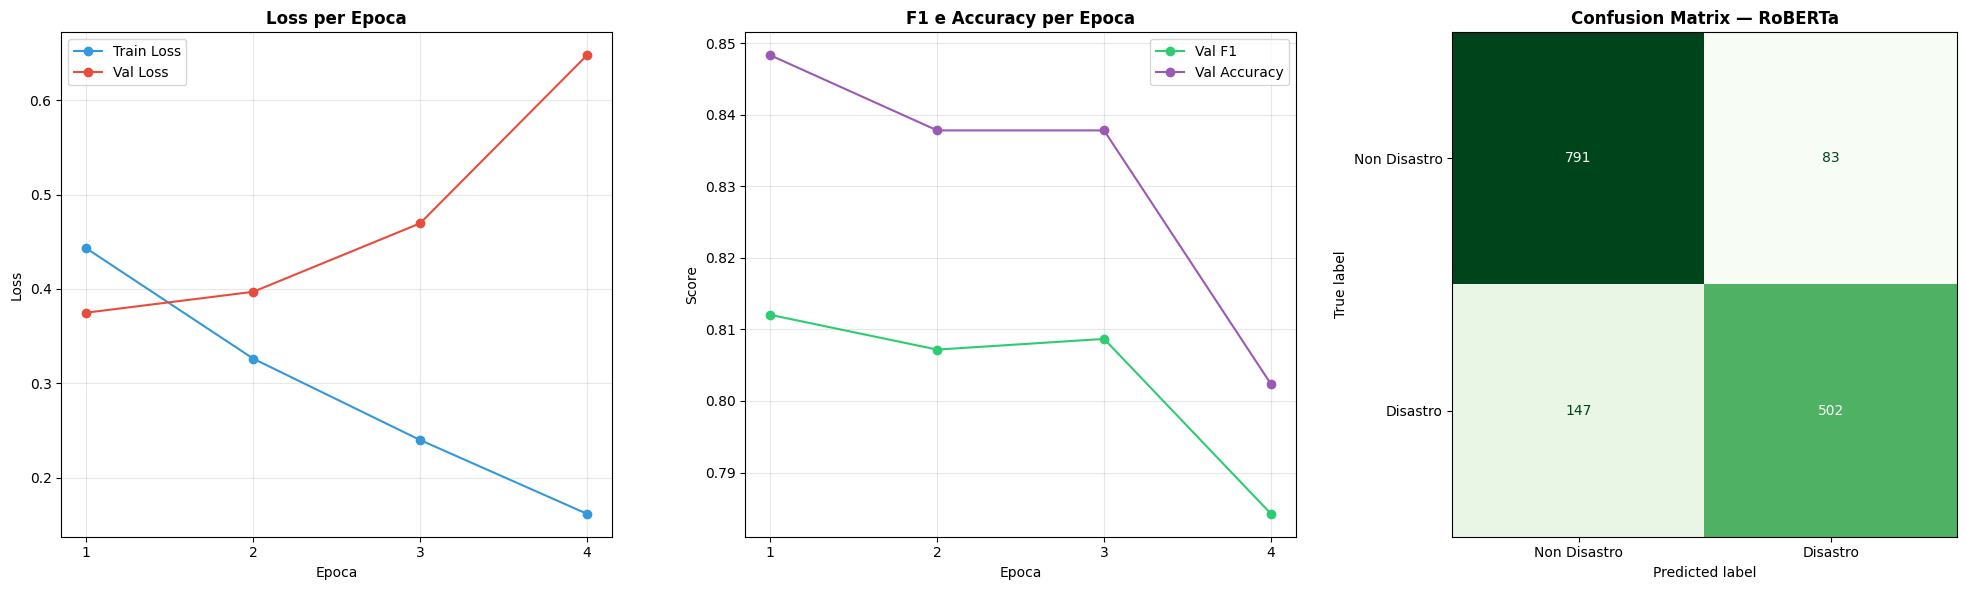

In [ ]:
actual_epochs = len(history['train_loss'])
plot_ep_range = list(range(1, actual_epochs + 1))

fig, axs = plt.subplots(1, 3, figsize=(20, 6))

axs[0].plot(plot_ep_range, history['train_loss'], marker='o', color='#3498db', label='Train Loss')
axs[0].plot(plot_ep_range, history['val_loss'], marker='o', color='#e74c3c', label='Val Loss')
axs[0].set_title('Loss per Epoca', fontweight='bold')
axs[0].set_xlabel('Epoca')
axs[0].set_ylabel('Loss')
axs[0].set_xticks(plot_ep_range)
axs[0].grid(True, alpha=0.3)
axs[0].legend()

axs[1].plot(plot_ep_range, history['val_f1'], marker='o', color='#2ecc71', label='Val F1')
axs[1].plot(plot_ep_range, history['val_acc'], marker='o', color='#9b59b6', label='Val Accuracy')
axs[1].set_title('F1 e Accuracy per Epoca', fontweight='bold')
axs[1].set_xlabel('Epoca')
axs[1].set_ylabel('Score')
axs[1].set_xticks(plot_ep_range)
axs[1].grid(True, alpha=0.3)
axs[1].legend()

cm_rob = confusion_matrix(all_labels, final_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rob, display_labels=['Non Disastro', 'Disastro'])
disp.plot(ax=axs[2], cmap='Greens', colorbar=False)
axs[2].set_title('Confusion Matrix — RoBERTa', fontweight='bold')
axs[2].grid(False)

plt.tight_layout()
plt.show()

L’overfitting del modello risulta evidente dal rapido crollo della loss sul training set e dal progressivo peggioramento della loss sul validation set, osservabile già a partire dalla prima epoca. Questo comportamento suggerisce che il modello, eccessivamente complesso rispetto alla dimensione ridotta del dataset (~7800 tweet), tenda ad adattarsi eccessivamente ai dati di addestramento, compromettendo la capacità di generalizzazione.

Modificando la soglia decisionale, il miglior risultato in termini di F1-score è stato ottenuto con una threshold pari a 0.49, che ha permesso di incrementare il punteggio da 0.8120 a 0.8136. Tuttavia, l’elevata complessità del modello, insieme alle risorse computazionali richieste e ai lunghi tempi di addestramento, non ne giustifica un utilizzo pratico in un contesto reale. Il suo impiego risulta quindi motivato principalmente dall’obiettivo di massimizzare l’F1-score nell’ambito della competition.


## Confronto Finale — Tutti i Modelli

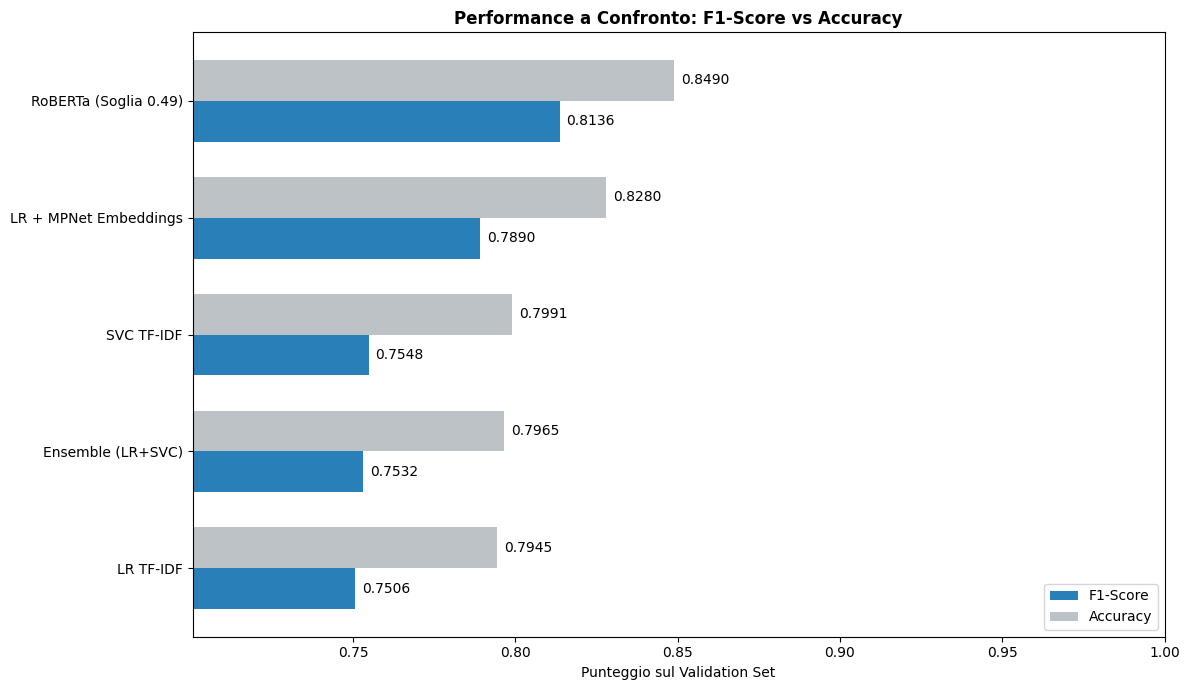

In [ ]:
risultati = [
    ('LR TF-IDF', metrics.f1_score(y_val, clf_lr.predict(X_val)), metrics.accuracy_score(y_val, clf_lr.predict(X_val))),
    ('SVC TF-IDF', metrics.f1_score(y_val, clf_SVC.predict(X_val)), metrics.accuracy_score(y_val, clf_SVC.predict(X_val))),
    ('Ensemble (LR+SVC)', metrics.f1_score(y_val, clf_EN.predict(X_val)), metrics.accuracy_score(y_val, clf_EN.predict(X_val))),
    ('LR + MPNet Embeddings', metrics.f1_score(y_val_emb, logistic_model_emb.predict(X_val_emb)), metrics.accuracy_score(y_val_emb, logistic_model_emb.predict(X_val_emb))),
    ('RoBERTa (Soglia %.2f)' % best_thresh, best_f1, final_acc)
]

risultati_ordinati = sorted(risultati, key=lambda x: x[1], reverse=False)
modelli, f1_scores, acc_scores = zip(*risultati_ordinati)

y = np.arange(len(modelli))
bar_height = 0.35

fig, ax = plt.subplots(figsize=(12, 7))

rects1 = ax.barh(y - bar_height/2, f1_scores, bar_height, label='F1-Score', color=(0.16, 0.5, 0.72, 1.0))
rects2 = ax.barh(y + bar_height/2, acc_scores, bar_height, label='Accuracy', color=(0.74, 0.76, 0.78, 1.0))

ax.bar_label(rects1, fmt='%.4f', padding=5)
ax.bar_label(rects2, fmt='%.4f', padding=5)

ax.set_yticks(y)
ax.set_yticklabels(modelli)
ax.set_xlabel('Punteggio sul Validation Set')
ax.set_title('Performance a Confronto: F1-Score vs Accuracy', fontweight='bold')

min_val = min(min(f1_scores), min(acc_scores))
ax.set_xlim(min_val - 0.05, 1.0)

ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

## Generazione Submission per Kaggle

In [ ]:
class TestTweetsDataset(Dataset):
    def __init__(self, texts, tokenizer, max_len=128):
        self.texts = texts
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, item):
        text = str(self.texts[item])
        inputs = self.tokenizer(
            text,
            add_special_tokens=True,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt',
        )
        return {
            'input_ids': inputs['input_ids'].flatten(),
            'attention_mask': inputs['attention_mask'].flatten()
        }

model.load_state_dict(torch.load('best_model.pt'))
model.eval()

test_texts = df_test['raw_full_text'].values
test_dataset = TestTweetsDataset(test_texts, tokenizer)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

test_probs = []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        probs = F.softmax(outputs.logits, dim=1)[:, 1]
        test_probs.extend(probs.cpu().numpy())

test_preds = (np.array(test_probs) > best_thresh).astype(int)

submission = pd.DataFrame({'id': df_test['id'],'target': test_preds})

submission.to_csv('submission.csv', index=False)